# Volatility-aware spread width

I use fixed seeds here so the numerical examples remain comparable when the implementation changes.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
pd.set_option("display.max_columns", 30)

I separate two controls here: estimated volatility changes total width, while inventory continues to change asymmetry. The regime-switching path shows the lag in the EWMA response.

In [2]:
path=pd.read_csv(ROOT/"outputs/data/representative_regime_switching_full_adaptive_intervals.csv")
path[["time_start","process_volatility","estimated_volatility","target_half_spread","effective_half_spread"]].head()

,time_start,process_volatility,estimated_volatility,target_half_spread,effective_half_spread
0,0.000,0.55,1.000000,0.084785,0.090
1,0.004,0.55,0.972827,0.083840,0.090
2,0.008,0.55,0.950592,0.083066,0.085
3,0.012,0.55,0.922690,0.082096,0.085
4,0.016,0.55,0.894769,0.081125,0.090


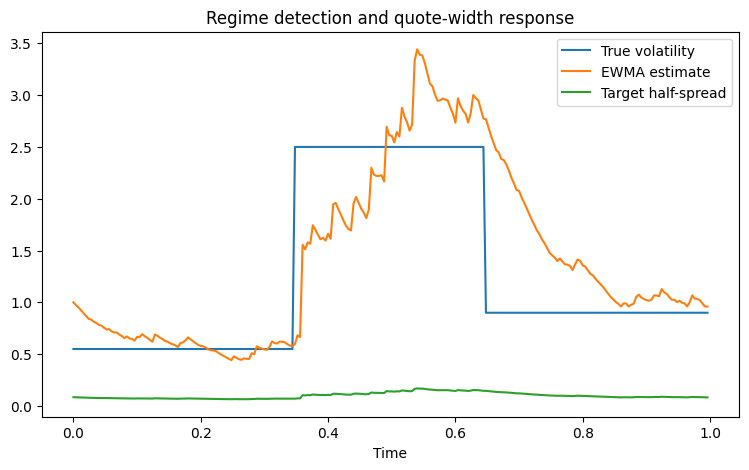

In [3]:
plt.figure(figsize=(9,5)); plt.plot(path.time_start,path.process_volatility,label="True volatility"); plt.plot(path.time_start,path.estimated_volatility,label="EWMA estimate"); plt.plot(path.time_start,path.target_half_spread,label="Target half-spread"); plt.xlabel("Time"); plt.legend(); plt.title("Regime detection and quote-width response"); plt.show()

In [4]:
pd.read_csv(ROOT/"outputs/tables/robustness_volatility.csv")[["volatility_sensitivity","mean_terminal_pnl","pnl_5_percentile","mean_traded_quantity","mean_absolute_inventory"]]

,volatility_sensitivity,mean_terminal_pnl,pnl_5_percentile,mean_traded_quantity,mean_absolute_inventory
0,0.00,1.551690,-8.266590,66.944444,2.040079
1,0.25,-0.263266,-15.948951,27.388889,1.856746
2,0.55,-0.730311,-11.137140,9.388889,1.377381
3,1.00,0.406376,-4.318761,1.944444,0.682540
